In [72]:
import numpy as np
import matplotlib.pyplot as plt
import sinter

In [73]:
tasks = sinter.stats_from_csv_files("/home/fidel/Projects/corrqec2/data/experiment1_syndrome.csv")

In [74]:
def calc_xi(a, b):
    return - 1 / np.log(1 - a - b)

def xi_to_Delta(xi):
    return 1 - np.exp(-1/xi)

def Delta_to_xi(Delta):
    return -1 / np.log(1 - Delta)

def calc_per_round(per_shot: float, rounds: int):        
    return 0.5 * (1 - (1 - 2 * per_shot) ** (1/rounds))


distances = [5, 7, 9, 11, 13, 15, 17, 19]
xis = [2, 4, 6, 8, 12, 16, 20, 28]
results_dict = {distance: {xi: None for xi in xis} for distance in distances}

for task in tasks:
    
    distance = task.json_metadata['experiment_args']['distance']
    model_params = task.json_metadata['noise_model_args']['model_params']
    rounds_mult = int(task.json_metadata['experiment_args']['rounds'][0])
    n_rounds = distance * rounds_mult
    a, b = model_params['a'], model_params['b']
    xi = int(np.round(calc_xi(a, b)))
    shots = task.shots
    errors = task.errors
    per_shot = errors / shots
    per_round = calc_per_round(per_shot, n_rounds)
    results_dict[distance][xi] = per_round
    # print(f"Distance: {distance}, xi: {xi}")

/tmp/ipykernel_61339/2224948513.py:8: RuntimeWarning: divide by zero encountered in divide
  return -1 / np.log(1 - Delta)


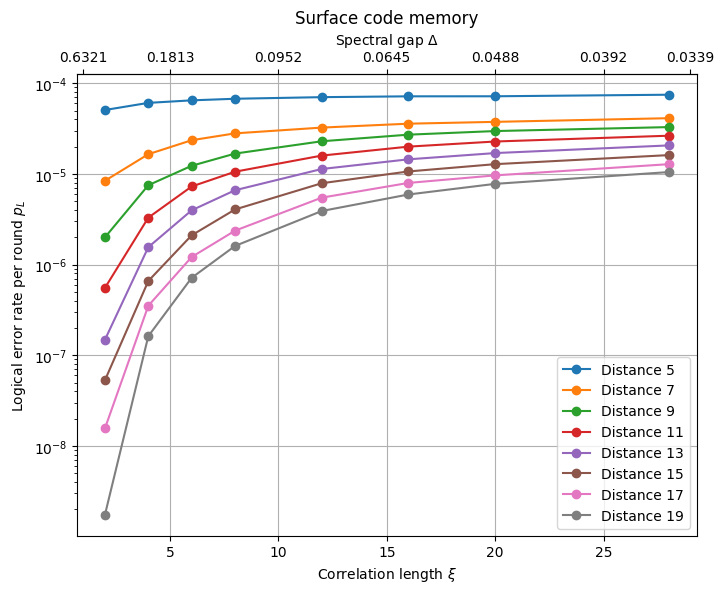

In [75]:
fig, ax = plt.subplots(figsize=(8, 6))
for distance in distances:
    xi_values = sorted(results_dict[distance].keys())
    logical_error_rates = [results_dict[distance][xi] for xi in xi_values]
    ax.plot(xi_values, logical_error_rates, marker='o', label=f'Distance {distance}')
ax.semilogy()
ax.grid(True)
ax.set_xlabel('Correlation length $\\xi$')
ax.set_ylabel('Logical error rate per round $p_{L}$')
ax.set_title('Surface code memory')
secax = ax.secondary_xaxis('top', functions=(xi_to_Delta, Delta_to_xi))
# secax.set_xscale('log')
secax.set_xlabel('Spectral gap $\\Delta$')
delta_ticks = [np.round(xi_to_Delta(xi), 4) for xi in [1, 5, 10, 15, 20, 25, 29]]
secax.set_xticks(delta_ticks)

ax.legend()

## Stability

In [76]:
tasks = sinter.stats_from_csv_files("/home/fidel/Projects/corrqec2/data/experiment2_results.csv")

In [77]:
def calc_xi(a, b):
    return - 1 / np.log(1 - a - b)

def xi_to_Delta(xi):
    return 1 - np.exp(-1/xi)

def Delta_to_xi(Delta):
    return -1 / np.log(1 - Delta)

def calc_per_round(per_shot: float, rounds: int):        
    return 0.5 * (1 - (1 - 2 * per_shot) ** (1/rounds))


rounds_list = [5, 10, 15, 20, 25, 30]
xis = [2, 3, 4, 5, 6, 8, 10]
results_dict = {rounds: {xi: None for xi in xis} for rounds in rounds_list}

for task in tasks:
    distance = task.json_metadata['experiment_args']['distance']
    model_params = task.json_metadata['noise_model_args']['model_params']
    rounds = task.json_metadata['experiment_args']['rounds']
    n_rounds = distance * rounds_mult
    a, b = model_params['a'], model_params['b']
    xi = int(np.round(calc_xi(a, b)))
    shots = task.shots
    errors = task.errors
    per_shot = errors / shots
    per_round = calc_per_round(per_shot, n_rounds)
    results_dict[rounds][xi] = per_round
    # print(f"Distance: {distance}, xi: {xi}")

/tmp/ipykernel_61339/1705817931.py:8: RuntimeWarning: divide by zero encountered in divide
  return -1 / np.log(1 - Delta)


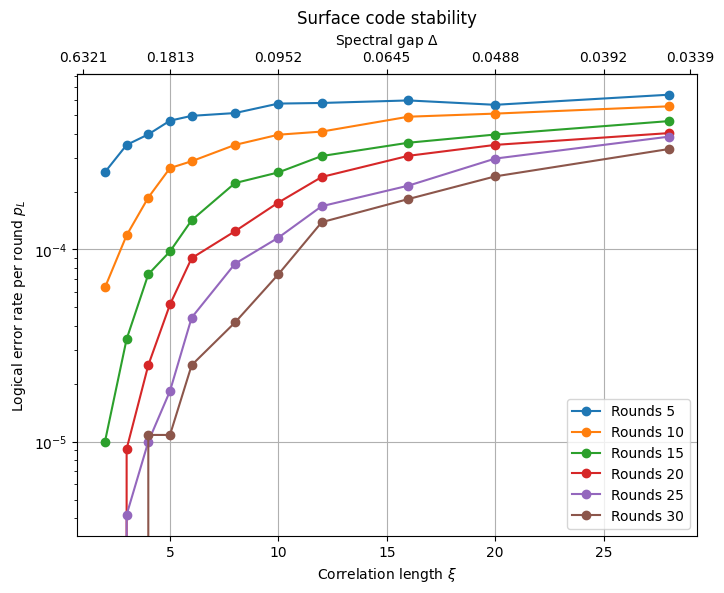

In [78]:
fig, ax = plt.subplots(figsize=(8, 6))
for rounds in rounds_list:
    xi_values = sorted(results_dict[rounds].keys())
    logical_error_rates = [results_dict[rounds][xi] for xi in xi_values]
    ax.plot(xi_values, logical_error_rates, marker='o', label=f'Rounds {rounds}')
ax.semilogy()
ax.grid(True)
ax.set_xlabel('Correlation length $\\xi$')
ax.set_ylabel('Logical error rate per round $p_{L}$')
ax.set_title('Surface code stability')
secax = ax.secondary_xaxis('top', functions=(xi_to_Delta, Delta_to_xi))
# secax.set_xscale('log')
secax.set_xlabel('Spectral gap $\\Delta$')
delta_ticks = [np.round(xi_to_Delta(xi), 4) for xi in [1, 5, 10, 15, 20, 25, 29]]
secax.set_xticks(delta_ticks)

ax.legend()